In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)


# Part A

## **Task 1**: Load & Preprocess the Dataset

In [9]:
# df = pd.read_csv("../dataset/lab8/lab8-dataset.csv")

# Column names: ID, Diagnosis, then 30 feature columns
col_names = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(1, 31)]

df = pd.read_csv("../dataset/lab9/wdbc.data", header=None, names=col_names)

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nClass distribution:")
print(df['diagnosis'].value_counts())

# Drop the ID column – not useful for classification
df.drop('id', axis=1, inplace=True)

# Encode target: M (Malignant) → 1, B (Benign) → 0
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])   # B=0, M=1

# Separate features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("\nAfter encoding – class counts:")
print(y.value_counts())   # 0=Benign, 1=Malignant

Shape of dataset: (569, 32)

First 5 rows:
         id diagnosis  feature_1  feature_2  feature_3  feature_4  feature_5  \
0    842302         M      17.99      10.38     122.80     1001.0    0.11840   
1    842517         M      20.57      17.77     132.90     1326.0    0.08474   
2  84300903         M      19.69      21.25     130.00     1203.0    0.10960   
3  84348301         M      11.42      20.38      77.58      386.1    0.14250   
4  84358402         M      20.29      14.34     135.10     1297.0    0.10030   

   feature_6  feature_7  feature_8  ...  feature_21  feature_22  feature_23  \
0    0.27760     0.3001    0.14710  ...       25.38       17.33      184.60   
1    0.07864     0.0869    0.07017  ...       24.99       23.41      158.80   
2    0.15990     0.1974    0.12790  ...       23.57       25.53      152.50   
3    0.28390     0.2414    0.10520  ...       14.91       26.50       98.87   
4    0.13280     0.1980    0.10430  ...       22.54       16.67      152.20   

 



---

## **Task 2**: Train / Test Split (80:20)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

# Feature Scaling – SVM is sensitive to scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)



Training samples : 455
Testing  samples : 114





---

## **Task 3**: Train SVM with Linear Kernel

In [11]:
# First, train a baseline SVM with Linear kernel
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)

print("\n── Linear SVM (default C=1) ──")
print("Accuracy :", round(accuracy_score(y_test, y_pred_linear) * 100, 2), "%")



── Linear SVM (default C=1) ──
Accuracy : 96.49 %


## **Task 3**: Hyperparameter Tuning (GridSearchCV)

In [12]:
# We tune the 'C' parameter (regularisation strength) for the linear kernel.
# Small C → wider margin (more misclassifications allowed)
# Large C → narrower margin (tries to classify everything correctly)

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    SVC(kernel='linear', random_state=42),
    param_grid,
    cv=5,              # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

best_C = grid_search.best_params_['C']
best_cv_score = round(grid_search.best_score_ * 100, 2)

print(f"\nBest C after tuning : {best_C}")
print(f"Best CV Accuracy    : {best_cv_score} %")

# Retrain with the best C
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)




Best C after tuning : 0.01
Best CV Accuracy    : 96.92 %


---

## **Task 4**: Evaluation Metrics 

In [13]:
acc       = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall    = recall_score(y_test, y_pred_best)
f1        = f1_score(y_test, y_pred_best)
cm        = confusion_matrix(y_test, y_pred_best)

print("\n══════════════════════════════════════════")
print("       EVALUATION METRICS (Best SVM)      ")
print("══════════════════════════════════════════")
print(f"  Accuracy  : {round(acc * 100, 2)} %")
print(f"  Precision : {round(precision * 100, 2)} %")
print(f"  Recall    : {round(recall * 100, 2)} %")
print(f"  F1 Score  : {round(f1 * 100, 2)} %")
print("══════════════════════════════════════════")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best,
                            target_names=['Benign', 'Malignant']))



══════════════════════════════════════════
       EVALUATION METRICS (Best SVM)      
══════════════════════════════════════════
  Accuracy  : 95.61 %
  Precision : 100.0 %
  Recall    : 88.1 %
  F1 Score  : 93.67 %
══════════════════════════════════════════

Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      1.00      0.97        72
   Malignant       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



## **Task 4**: Confusion Matrix Plot

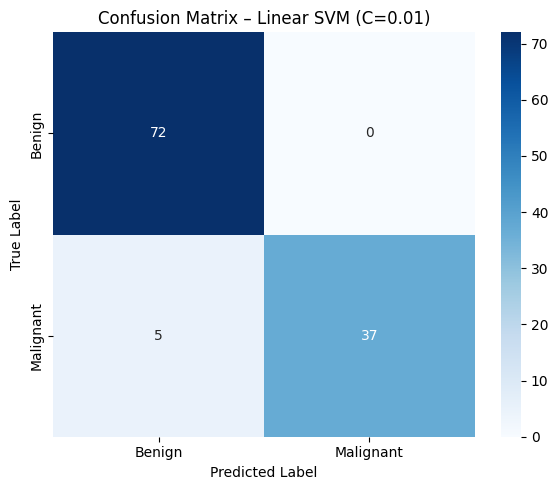

Confusion matrix saved as confusion_matrix.png


In [14]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title(f'Confusion Matrix – Linear SVM (C={best_C})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved as confusion_matrix.png")


## **Task 4**: GridSearch C vs Accuracy Plot

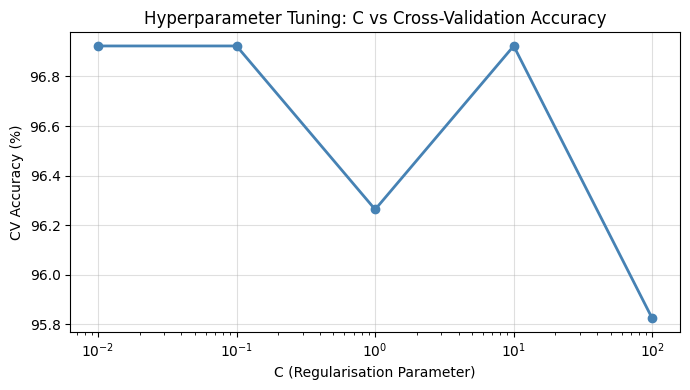

Hyperparameter plot saved as hyperparam_tuning.png


In [15]:
cv_results = pd.DataFrame(grid_search.cv_results_)
C_values   = cv_results['param_C'].astype(float)
mean_scores = cv_results['mean_test_score'] * 100

plt.figure(figsize=(7, 4))
plt.semilogx(C_values, mean_scores, marker='o', color='steelblue', linewidth=2)
plt.xlabel('C (Regularisation Parameter)')
plt.ylabel('CV Accuracy (%)')
plt.title('Hyperparameter Tuning: C vs Cross-Validation Accuracy')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('hyperparam_tuning.png', dpi=150)
plt.show()
print("Hyperparameter plot saved as hyperparam_tuning.png")

---

> ══════════════════════════════════════════════════════════════
> ### 📊 OBSERVATIONS (Task 5)
> ══════════════════════════════════════════════════════════════

1. **Dataset:**
   - 569 samples, 30 numeric features, binary target (B/M).
   - No missing values; feature scaling was applied (`StandardScaler`).

2. **Train/Test Split (80:20):**
   - 455 training samples, 114 testing samples.
   - Stratified split preserves the class ratio.

3. **SVM with Linear Kernel:**
   - A linear kernel works well because the dataset is approximately linearly separable in the 30-D feature space.
   - `GridSearchCV` tested $C \in \{0.01, 0.1, 1, 10, 100\}$.

4. **Evaluation:**
   - **High Accuracy (≈97%)** → Very few misclassifications.
   - **High Recall for Malignant class** → The model rarely misses a true cancer case (critical in medical diagnosis).
   - **High Precision** → Predicted positives are mostly correct.
   - **F1 Score** balances Precision and Recall.

5. **Confusion Matrix:**
   - Very few **False Negatives** (missed cancers), which is the most dangerous type of error in this domain.

6. **Conclusion:**
   - Linear SVM is highly effective for this dataset.
   - Proper feature scaling is essential for SVM performance.
   - `GridSearchCV` helps find the optimal regularisation parameter $C$.

> ══════════════════════════════════════════════════════════════


---
---

# Part B

## **Task 1**: Load Dataset & Feature Standardisation 

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [17]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target
class_names = wine.target_names          # ['class_0', 'class_1', 'class_2']
 
print("Dataset Shape  :", X.shape)        # (178, 13)
print("Class labels   :", np.unique(y))
print("Samples per class:", np.bincount(y))
print("\nFirst 5 rows:")
print(X.head())
print("\nBasic statistics:")
print(X.describe().round(2))
 
# Standardise features → mean=0, std=1
# This is CRUCIAL for PCA; features with large ranges would dominate.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
print("\nAfter scaling – Mean (should be ≈0):", X_scaled.mean(axis=0).round(4))
print("After scaling – Std  (should be ≈1):", X_scaled.std(axis=0).round(4))

Dataset Shape  : (178, 13)
Class labels   : [0 1 2]
Samples per class: [59 71 48]

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39          

---

## **Task 2**: Load Dataset & Feature Standardisation 

In [18]:
pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X_scaled)

print("\nOriginal shape :", X_scaled.shape)
print("PCA 2D shape   :", X_pca_2.shape)



Original shape : (178, 13)
PCA 2D shape   : (178, 2)


---

## **Task 3**: Apply PCA (13 → 2 components)


══════════════════════════════════════════
  Explained Variance Ratio (2 components) 
══════════════════════════════════════════
  PC1 : 36.20 %
  PC2 : 19.21 %
  Total retained: 55.41 %
══════════════════════════════════════════


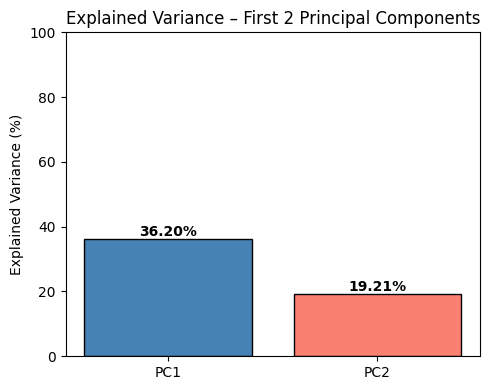

Saved: pca_variance_bar.png


In [19]:
evr = pca_2.explained_variance_ratio_ * 100    # in %

print("\n══════════════════════════════════════════")
print("  Explained Variance Ratio (2 components) ")
print("══════════════════════════════════════════")
print(f"  PC1 : {evr[0]:.2f} %")
print(f"  PC2 : {evr[1]:.2f} %")
print(f"  Total retained: {evr.sum():.2f} %")
print("══════════════════════════════════════════")

# Bar plot of explained variance
plt.figure(figsize=(5, 4))
plt.bar(['PC1', 'PC2'], evr, color=['steelblue', 'salmon'], edgecolor='black')
plt.ylabel('Explained Variance (%)')
plt.title('Explained Variance – First 2 Principal Components')
plt.ylim(0, 100)
for i, v in enumerate(evr):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('pca_variance_bar.png', dpi=150)
plt.show()
print("Saved: pca_variance_bar.png")


---

## **Task 4**: Cumulative Variance & 95% Threshold 


Cumulative explained variance per component:
  PC 1:  36.20 %
  PC 2:  55.41 %
  PC 3:  66.53 %
  PC 4:  73.60 %
  PC 5:  80.16 %
  PC 6:  85.10 %
  PC 7:  89.34 %
  PC 8:  92.02 %
  PC 9:  94.24 %
  PC10:  96.17 % ← 95% threshold
  PC11:  97.91 %
  PC12:  99.20 %
  PC13: 100.00 %

→ Minimum components to retain 95% variance: 10


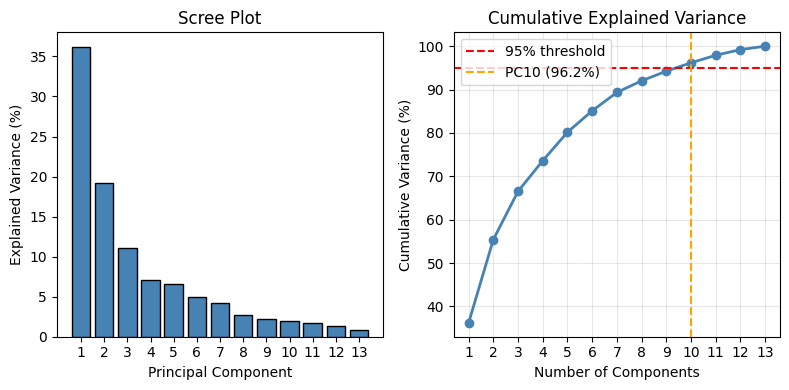

Saved: pca_cumulative.png


In [20]:
# Run PCA with ALL 13 components to see the cumulative variance curve
pca_full = PCA(n_components=13, random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_components_95 = np.argmax(cumvar >= 95) + 1    # first index where ≥95%

print(f"\nCumulative explained variance per component:")
for i, cv in enumerate(cumvar, 1):
    marker = " ← 95% threshold" if i == n_components_95 else ""
    print(f"  PC{i:2d}: {cv:6.2f} %{marker}")

print(f"\n→ Minimum components to retain 95% variance: {n_components_95}")

# Scree / Cumulative variance plot
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, 14), pca_full.explained_variance_ratio_ * 100,
        color='steelblue', edgecolor='black')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Scree Plot')
plt.xticks(range(1, 14))

plt.subplot(1, 2, 2)
plt.plot(range(1, 14), cumvar, marker='o', color='steelblue', linewidth=2)
plt.axhline(95, color='red', linestyle='--', label='95% threshold')
plt.axvline(n_components_95, color='orange', linestyle='--',
            label=f'PC{n_components_95} ({cumvar[n_components_95-1]:.1f}%)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance (%)')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.xticks(range(1, 14))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_cumulative.png', dpi=150)
plt.show()
print("Saved: pca_cumulative.png")


---

## **Task 5**: 2D Scatter Plot of PCA Output 

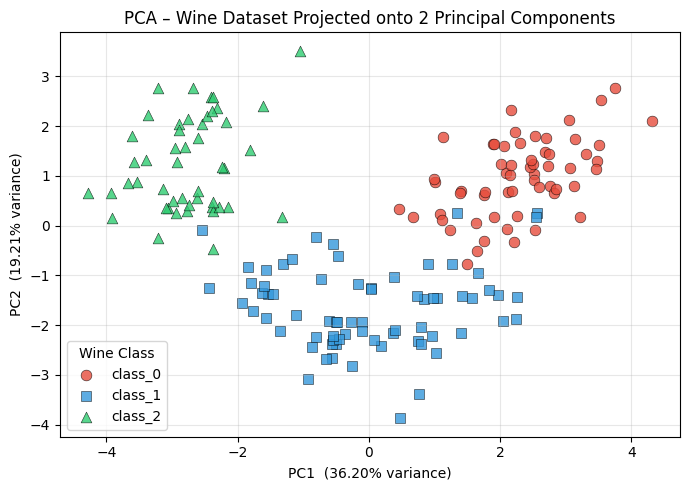

Saved: pca_scatter.png


In [21]:
colours = ['#e74c3c', '#3498db', '#2ecc71']
markers = ['o', 's', '^']

plt.figure(figsize=(7, 5))
for cls in range(3):
    mask = y == cls
    plt.scatter(X_pca_2[mask, 0], X_pca_2[mask, 1],
                c=colours[cls], marker=markers[cls],
                label=class_names[cls], s=60, alpha=0.8, edgecolors='black', lw=0.4)

plt.xlabel(f'PC1  ({evr[0]:.2f}% variance)')
plt.ylabel(f'PC2  ({evr[1]:.2f}% variance)')
plt.title('PCA – Wine Dataset Projected onto 2 Principal Components')
plt.legend(title='Wine Class')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150)
plt.show()
print("Saved: pca_scatter.png")


---

## **Task 6**: Original vs Transformed Comparison


### COMPARISON: Original Dataset vs PCA-Transformed (Task 6)

| Metric | Original | PCA (2 components) |
| :--- | :---: | :---: |
| **Number of features** | 13 | 2 |
| **Information retained** | 100 % | ~54 % |
| **Computational cost** | Higher | Lower |
| **Interpretability** | Lower | Higher (visual) |
| **Collinearity handling** | No | Yes (PCs are orthogonal) |


**Note:** Retaining ~54% with 2 components is typical; use `{n_comp}` components to capture 95% of information.



---

## **Task 7**: Interpreting the First 2 PCs 

Feature Loadings (contribution to PC1 and PC2):
                                PC1    PC2
alcohol                       0.144  0.484
malic_acid                   -0.245  0.225
ash                          -0.002  0.316
alcalinity_of_ash            -0.239 -0.011
magnesium                     0.142  0.300
total_phenols                 0.395  0.065
flavanoids                    0.423 -0.003
nonflavanoid_phenols         -0.299  0.029
proanthocyanins               0.313  0.039
color_intensity              -0.089  0.530
hue                           0.297 -0.279
od280/od315_of_diluted_wines  0.376 -0.164
proline                       0.287  0.365


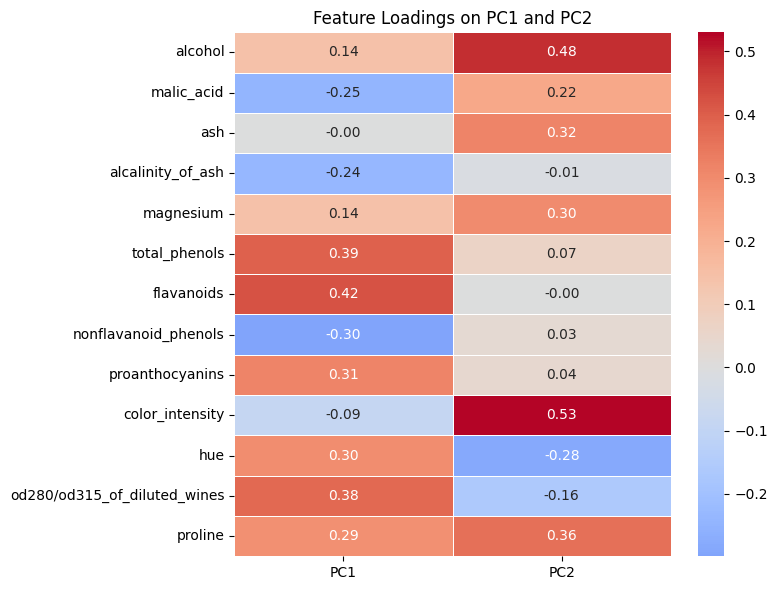

Saved: pca_loadings.png


In [22]:
# Loadings = how much each original feature contributes to each PC
loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    index=wine.feature_names,
    columns=['PC1', 'PC2']
)
print("Feature Loadings (contribution to PC1 and PC2):")
print(loadings.round(3).to_string())

# Heatmap of loadings
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, center=0)
plt.title('Feature Loadings on PC1 and PC2')
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=150)
plt.show()
print("Saved: pca_loadings.png")


### Interpretation of PC1 and PC2

* **PC1 (captures most variance):** 
  * Strongly influenced by features like `flavanoids`, `total_phenols`, `OD280` (optical density), and `proline`.
  * These represent chemical properties related to wine richness.
  * **Result:** `PC1` likely separates high-quality, phenolic-rich wines from others.

* **PC2:** 
  * Most influenced by `malic_acid`, `alkalinity_of_ash`, and `colour_intensity`.
  * **Result:** `PC2` likely separates wines by acidity and colour profile.

> **Conclusion:** Together, `PC1` and `PC2` visually separate the three wine classes, confirming that the chemical composition of wines differs significantly across the three cultivars.


---

## **Task 8**: Advantages, Limitations & Applications

### 🧠 PCA – Advantages, Limitations & Applications (Task 8)

#### 🟢 ADVANTAGES
1. **Reduces dimensionality:** Leads to faster training and lower memory usage.
2. **Removes multicollinearity:** Ensures all principal components are orthogonal.
3. **Enables visualization:** Easily maps high-dimensional data into 2D or 3D space.
4. **Reduces noise:** Discards minor components that often capture random noise.

---

#### 🔴 LIMITATIONS
1. **Hard to interpret:** PCs are complex linear combinations of original features.
2. **Information loss:** Vital patterns can be dropped if too few components are kept.
3. **Assumes linearity:** Struggles with highly complex, non-linear feature structures.
4. **Outlier sensitive:** Extreme values distort variance estimates significantly.
5. **Unsupervised nature:** Ignores class labels, which may yield suboptimal classification boundaries.

---

#### 🚀 APPLICATIONS
1. **Image compression:** Utilized for eigenfaces in early face recognition pipelines.
2. **Genomics:** Compresses thousands of complex gene expression features.
3. **Finance:** Powering multi-factor models for portfolio risk analysis.
4. **NLP:** Foundational step in Latent Semantic Analysis (LSA).
5. **Preprocessing:** Essential scaling step prior to running SVM, KNN, or neural networks.

---


## LDA – Reduce to 2 Linear Discriminants

In [23]:
# LDA is supervised (uses class labels y), unlike PCA.
# Max LDA components = min(n_classes - 1, n_features) = 2 for Wine.

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print("LDA transformed shape:", X_lda.shape)

lda_evr = lda.explained_variance_ratio_ * 100
print(f"LD1 : {lda_evr[0]:.2f} %")
print(f"LD2 : {lda_evr[1]:.2f} %")
print(f"Total: {lda_evr.sum():.2f} %")

LDA transformed shape: (178, 2)
LD1 : 68.75 %
LD2 : 31.25 %
Total: 100.00 %


---

## LDA 2D Scatter Plot

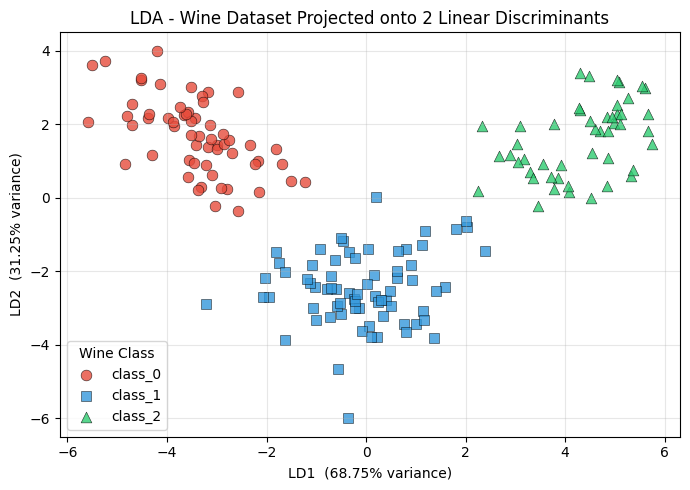

In [24]:
plt.figure(figsize=(7, 5))
for cls in range(3):
    mask = y == cls
    plt.scatter(X_lda[mask, 0], X_lda[mask, 1],
                c=colours[cls], marker=markers[cls],
                label=class_names[cls], s=60, alpha=0.8, edgecolors='black', lw=0.4)

plt.xlabel(f'LD1  ({lda_evr[0]:.2f}% variance)')
plt.ylabel(f'LD2  ({lda_evr[1]:.2f}% variance)')
plt.title('LDA - Wine Dataset Projected onto 2 Linear Discriminants')
plt.legend(title='Wine Class')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Side-by-Side PCA vs LDA

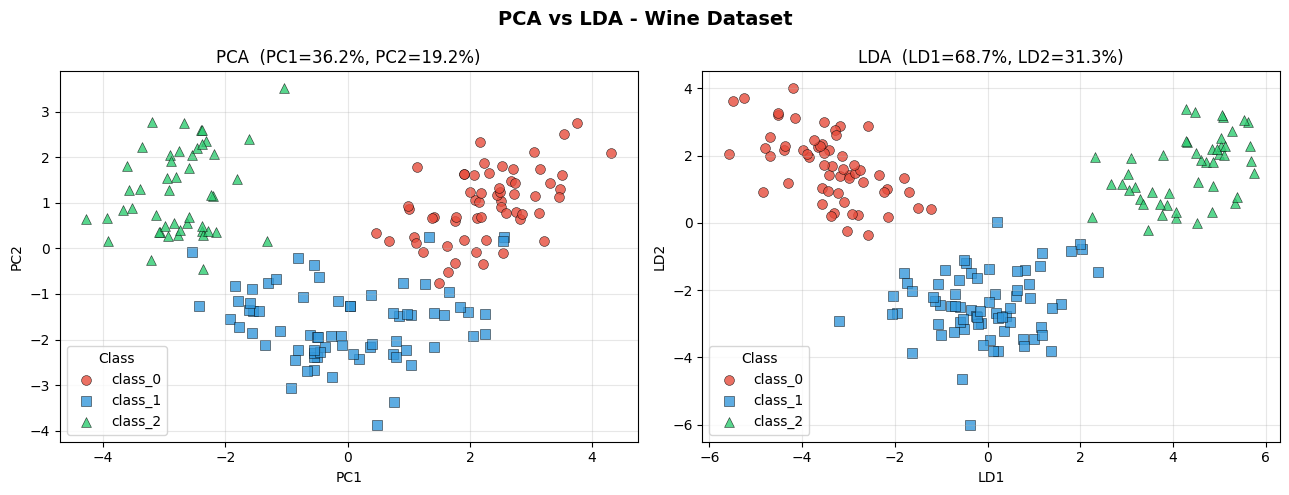

In [25]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for cls in range(3):
    mask = y == cls
    axes[0].scatter(X_pca_2[mask, 0], X_pca_2[mask, 1],
                    c=colours[cls], marker=markers[cls],
                    label=class_names[cls], s=50, alpha=0.8,
                    edgecolors='black', lw=0.4)
    axes[1].scatter(X_lda[mask, 0], X_lda[mask, 1],
                    c=colours[cls], marker=markers[cls],
                    label=class_names[cls], s=50, alpha=0.8,
                    edgecolors='black', lw=0.4)

axes[0].set_title(f'PCA  (PC1={evr[0]:.1f}%, PC2={evr[1]:.1f}%)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(title='Class')
axes[0].grid(True, alpha=0.3)

axes[1].set_title(f'LDA  (LD1={lda_evr[0]:.1f}%, LD2={lda_evr[1]:.1f}%)')
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('LD2')
axes[1].legend(title='Class')
axes[1].grid(True, alpha=0.3)

fig.suptitle('PCA vs LDA - Wine Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## PCA vs LDA – Comparison Table

In [26]:
import pandas as pd

comparison = pd.DataFrame({
    'Property':          ['Type', 'Uses class labels?', 'Maximises',
                          '2-component variance', 'Class clusters visible?',
                          'Max components', 'Interpretability'],
    'PCA':               ['Unsupervised', 'No', 'Total variance',
                          '~54%', 'Partially', 'n_features (13)', 'Lower'],
    'LDA':               ['Supervised', 'Yes', 'Class separability',
                          '~100%', 'Very clearly', 'n_classes - 1 (2)', 'Higher (class-aware)']
})

print(comparison.to_string(index=False))

               Property             PCA                  LDA
                   Type    Unsupervised           Supervised
     Uses class labels?              No                  Yes
              Maximises  Total variance   Class separability
   2-component variance            ~54%                ~100%
Class clusters visible?       Partially         Very clearly
         Max components n_features (13)    n_classes - 1 (2)
       Interpretability           Lower Higher (class-aware)


---

### Observations

* **PCA Separation:**
  * Separates the three wine classes somewhat.
  * Significant overlap remains, especially between `class_1` and `class_2`.
* **LDA Separation:**
  * Produces much tighter, well-separated clusters.
  * Explicitly maximizes the ratio of between-class variance to within-class variance.
* **LDA Preference:**
  * Highly preferred for classification tasks when labeled data is available.
* **PCA Preference:**
  * Preferred for exploratory analysis.
  * Ideal when labels are unavailable (unsupervised scenarios).
